In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.cluster import DBSCAN
from sklearn.cluster import OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.graph_objects as go
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [2]:
from pathlib import Path

# CRITICO: .resolve() per path assoluto — Path(".").parent == Path(".") (non sale!)
_HERE = Path(".").resolve()

# ── customer features (output di cleaning_data.ipynb) ───────────────────────
_candidates_custom = [
    _HERE / "customer_features_final_clean.csv",
    _HERE.parent / "customer_features_final_clean.csv",
    _HERE.parent.parent / "customer_features_final_clean.csv",
    _HERE / "customer_features_with_clusters.csv",
    _HERE.parent / "customer_features_with_clusters.csv",
    _HERE.parent.parent / "customer_features_with_clusters.csv",  # data science in action/
    _HERE / "io" / "customer_features_with_clusters.csv",
    _HERE.parent / "io" / "customer_features_with_clusters.csv",
]

custom_path = next((p for p in _candidates_custom if p.exists()), None)
if custom_path is None:
    raise FileNotFoundError(
        "File customer features non trovato. "
        "Esegui prima src/cleaning_data.ipynb oppure copia "
        "customer_features_with_clusters.csv nella root del progetto."
    )

print(f"Caricamento customer features da: {custom_path}")
custom = pd.read_csv(custom_path)
print(f"Shape: {custom.shape}")

# ── master transactions (opzionale, per feature aggiuntive) ─────────────────
master = None
for _candidate in [
    _HERE / "master_transactions.csv",
    _HERE.parent / "master_transactions.csv",
    _HERE.parent.parent / "master_transactions.csv",        # data science in action/
    _HERE.parent.parent.parent / "master_transactions.csv", # Desktop/ (fallback)
    _HERE / "io" / "master_transactions.csv",
    _HERE.parent / "io" / "master_transactions.csv",
]:
    if _candidate.exists():
        master = pd.read_csv(_candidate)
        print(f"Master transactions caricato da: {_candidate}  shape: {master.shape}")
        break

if master is None:
    print("master_transactions.csv non trovato - si procede solo con customer features.")


Caricamento customer features da: /Users/antonellamosca/Desktop/data science in action/customer_features_final_clean.csv
Shape: (21480, 32)
Master transactions caricato da: /Users/antonellamosca/Desktop/data science in action/master_transactions.csv  shape: (102655, 24)


# Feature engineering and preprocessing

In [3]:
if master is not None and {'list_price', 'Quantity', 'customer_id'}.issubset(master.columns):
    # 1. Calculate the actual Transaction Value for every row
    master['transaction_value'] = master['list_price'] * master['Quantity']

    # 2. Group by Customer to find the 'Net Spenders'
    customer_financials = master.groupby('customer_id').agg(
        total_net_spend=('transaction_value', 'sum'),
        total_items_handled=('Quantity', 'sum'),
        transaction_count=('customer_id', 'count')
    )

    # 3. Identify customers where Total Net Spend is negative
    negative_spend_ids = customer_financials[customer_financials['total_net_spend'] < 0].index.tolist()

    # 4. Extract their full history from the Master DF
    negative_audit_df = master[master['customer_id'].isin(negative_spend_ids)].copy()
    if 'Date' in negative_audit_df.columns:
        negative_audit_df = negative_audit_df.sort_values(by=['customer_id', 'Date'])
    else:
        negative_audit_df = negative_audit_df.sort_values(by=['customer_id'])

    # 5. Export to CSV
    negative_audit_df.to_csv('negative_spend_audit_detailed.csv', index=False)

    print(f"Found {len(negative_spend_ids)} customers with a negative total balance.")
    print("Detailed transaction history saved to 'negative_spend_audit_detailed.csv'")

    # Quick look at the 'Top Returners' by value
    print("\nCustomers with the most negative balances:")
    print(customer_financials.loc[negative_spend_ids].sort_values('total_net_spend').head())
else:
    print('Skipping negative-spend audit: transactional columns not available.')

Found 52 customers with a negative total balance.
Detailed transaction history saved to 'negative_spend_audit_detailed.csv'

Customers with the most negative balances:
             total_net_spend  total_items_handled  transaction_count
customer_id                                                         
H0427042             -1602.5                   -6                 38
F0962981              -648.0                   -6                 19
L0411143              -629.0                   -4                 21
E0474206              -574.5                   -2                 14
L0532629              -510.0                   -4                 12


### 52 customers received multiple (2-3) returns for each product they bought and returned. The subsequent returns occured usually a week or two after the initial return

In [4]:
# Remove columns that could conflict with recalculated fields in this notebook
custom = custom.drop(columns=['cluster', 'recency_days', 'Gender', 'province'], errors='ignore')

In [5]:
if master is not None and {'list_price', 'Quantity', 'customer_id'}.issubset(master.columns):
    master['transaction_value'] = master['list_price'] * master['Quantity']

    # Calculate total lifetime value (LTV) for every customer in the dataset
    customer_check = master.groupby('customer_id')['transaction_value'].sum()

    # Keep only IDs with non-negative total spend
    valid_customer_ids = customer_check[customer_check >= 0].index

    # Create a clean master dataframe excluding negative spenders
    master = master[master['customer_id'].isin(valid_customer_ids)].copy()
else:
    print('Skipping master-level filtering: transactional dataset not available.')

In [6]:
# Convert Date only when a transactional dataset is available
if master is not None and 'Date' in master.columns:
    master['Date'] = pd.to_datetime(master['Date'], format='%d%b%Y', errors='coerce')
else:
    print('Skipping Date conversion: no transactional Date column found.')

In [7]:
# Build recency and demographics from transactional data when available
if master is not None and {'customer_id', 'Date'}.issubset(master.columns):
    # Reference date for Recency
    ref_date = master['Date'].max()

    # Recency: days since latest transaction
    recency_df = master.groupby('customer_id')['Date'].max().reset_index()
    recency_df['recency_days'] = (ref_date - recency_df['Date']).dt.days

    # Optional demographics from transactions
    available_demo_cols = [c for c in ['customer_id', 'Gender', 'province'] if c in master.columns]
    demographics = master[available_demo_cols].drop_duplicates('customer_id') if len(available_demo_cols) > 1 else None
else:
    recency_df = None
    demographics = None
    print('Transactional recency/demographics unavailable; using customer dataset fields only.')

In [8]:
# BUILD FINAL TABLE FOR CLUSTERING
df_final = custom.copy()

# Merge recency from transactions when available
if recency_df is not None and {'customer_id', 'recency_days'}.issubset(recency_df.columns):
    df_final = df_final.merge(recency_df[['customer_id', 'recency_days']], on='customer_id', how='left', suffixes=('', '_from_tx'))
    if 'recency_days_from_tx' in df_final.columns:
        df_final['recency_days'] = df_final['recency_days_from_tx'].combine_first(df_final.get('recency_days'))
        df_final = df_final.drop(columns=['recency_days_from_tx'])

# Merge demographics when available
if demographics is not None and 'customer_id' in demographics.columns:
    demo_cols = [c for c in demographics.columns if c != 'customer_id']
    if demo_cols:
        df_final = df_final.merge(demographics, on='customer_id', how='left', suffixes=('', '_from_tx'))
        for c in demo_cols:
            tx_col = f'{c}_from_tx'
            if tx_col in df_final.columns:
                df_final[c] = df_final[tx_col].combine_first(df_final.get(c))
                df_final = df_final.drop(columns=[tx_col])

In [9]:
# Handle missing recency
if 'recency_days' in df_final.columns:
    # If a customer has no recency, set a high value
    df_final['recency_days'] = df_final['recency_days'].fillna(600)
else:
    # If recency is completely unavailable, create a default value
    df_final['recency_days'] = 600
    print('recency_days not found; created default recency_days = 600 for all rows.')

In [10]:
# PREPROCESSING
# Use an expanded feature set from the new engineered dataset
candidate_num_cols = [
    'age_years', 'net_amount', 'transaction_count', 'return_rate_tx',
    'nl_open_rate', 'nl_click_rate', 'recency_days',
    'gross_spend', 'return_value', 'avg_ticket',
    'discounted_tx_rate', 'purchase_frequency_per_month', 'ecommerce_share'
]
num_cols = [c for c in candidate_num_cols if c in df_final.columns]

candidate_cat_cols = ['Gender', 'dominant_channel']
cat_cols = [c for c in candidate_cat_cols if c in df_final.columns]

if not num_cols:
    raise ValueError('No numeric columns available for clustering after merge.')

transformers = [('num', StandardScaler(), num_cols)]
if cat_cols:
    transformers.append(
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    )

preprocessor = ColumnTransformer(transformers=transformers)

# Drop rows missing selected modeling features
df_final = df_final.dropna(subset=num_cols + cat_cols)

X_scaled = preprocessor.fit_transform(df_final)

print('Numeric features used:', num_cols)
print('Categorical features used:', cat_cols)
print('Rows available for clustering:', len(df_final))

Numeric features used: ['recency_days', 'gross_spend', 'return_value', 'avg_ticket', 'discounted_tx_rate', 'purchase_frequency_per_month', 'ecommerce_share']
Categorical features used: ['Gender', 'dominant_channel']
Rows available for clustering: 21428


# K-means

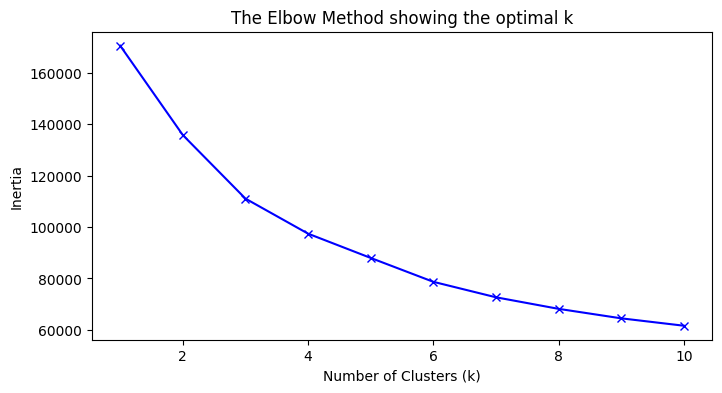

In [11]:
# ELBOW METHOD
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [12]:
# RUNNING K-MEANS 
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

In [13]:
# ANALYZE THE RESULTS
cluster_summary = df_final.groupby('cluster')[num_cols].mean()
print(cluster_summary)

         recency_days  gross_spend  return_value  avg_ticket  \
cluster                                                        
0          206.888368   337.987324      0.984235  133.565602   
1          254.858903   328.111234      9.462533  129.591791   
2          182.299643   720.826657    406.104340   49.274615   
3          112.452515  1191.499069     46.472204  144.985224   

         discounted_tx_rate  purchase_frequency_per_month  ecommerce_share  
cluster                                                                     
0                  0.746139                      1.262548         0.008202  
1                  0.064586                      1.240339         0.001871  
2                  0.091830                      1.932018         0.951257  
3                  0.264726                      2.299731         0.000391  


# DBSCAN

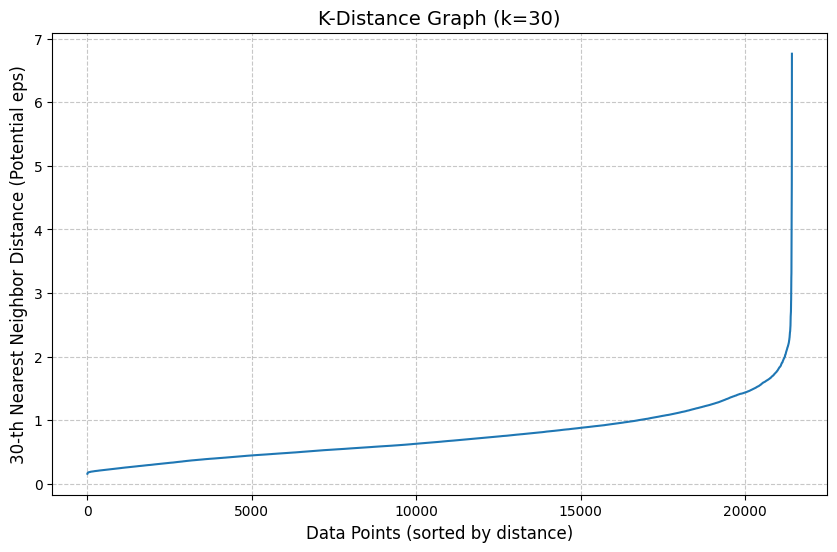

In [14]:
# Plot k-distance knee to find optimal epsilon (eps)
def plot_k_distance(data, k=30):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    
    distances, indices = neighbors_fit.kneighbors(data)

    k_distances = np.sort(distances[:, k-1], axis=0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_distances)
    plt.title(f'K-Distance Graph (k={k})', fontsize=14)
    plt.xlabel('Data Points (sorted by distance)', fontsize=12)
    plt.ylabel(f'{k}-th Nearest Neighbor Distance (Potential eps)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_k_distance(X_scaled, k=30)

In [15]:
# INITIALIZE DBSCAN
dbscan = DBSCAN(eps=1.8, min_samples=30)

clusters_dbscan = dbscan.fit_predict(X_scaled)

df_final['cluster_dbscan'] = clusters_dbscan

n_clusters_ = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_ = list(clusters_dbscan).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')

dbscan_summary = df_final[df_final['cluster_dbscan'] != -1].groupby('cluster_dbscan')[num_cols].mean()
print("\n--- DBSCAN Cluster Averages ---")
print(dbscan_summary)

Estimated number of clusters: 2
Estimated number of noise points: 56

--- DBSCAN Cluster Averages ---
                recency_days  gross_spend  return_value  avg_ticket  \
cluster_dbscan                                                        
0                 188.303550   665.390644    353.651775   53.063021   
1                 199.349225   597.349858     21.025079  134.859556   

                discounted_tx_rate  purchase_frequency_per_month  \
cluster_dbscan                                                     
0                         0.107752                      1.830189   
1                         0.286344                      1.575650   

                ecommerce_share  
cluster_dbscan                   
0                      0.997775  
1                      0.000145  


# OPTICS

In [16]:
# OPTICS will find the best epsilon for each cluster automatically
optics_model = OPTICS(min_samples=15, xi=0.05, min_cluster_size=0.05)
df_final['cluster_optics'] = optics_model.fit_predict(X_scaled)

print("--- OPTICS Cluster Sizes ---")
print(df_final['cluster_optics'].value_counts())

--- OPTICS Cluster Sizes ---
cluster_optics
-1    19783
 0     1645
Name: count, dtype: int64


### Hairball problem, DBSCAN and OPTICS won't work as the data is a "Global Density" mass -> no clear gaps between customer groups. Need centroid-based or distribution-based clustering

# Gaussian Mixture Model

In [17]:
# 1. Initialize GMM
gmm = GaussianMixture(n_components=4, random_state=42)

df_final['cluster_gmm'] = gmm.fit_predict(X_scaled)

gmm_summary = df_final.groupby('cluster_gmm')[num_cols].mean().round(2)
print("--- GMM Cluster Averages ---")
print(gmm_summary)

--- GMM Cluster Averages ---
             recency_days  gross_spend  return_value  avg_ticket  \
cluster_gmm                                                        
0                  173.71       701.22          0.00      140.97   
1                  270.37       271.60          0.00      138.84   
2                  188.19       676.01        359.80       54.64   
3                  141.62       966.66        247.19       80.63   

             discounted_tx_rate  purchase_frequency_per_month  ecommerce_share  
cluster_gmm                                                                     
0                          0.44                          1.73             0.00  
1                          0.00                          1.08             0.00  
2                          0.11                          1.84             0.99  
3                          0.17                          2.17             0.00  


In [18]:
# cluster sizes
print("--- Raw Cluster Sizes ---")
print(df_final['cluster_gmm'].value_counts())

print("\n--- Percentage Breakdown ---")
print(df_final['cluster_gmm'].value_counts(normalize=True) * 100)

--- Raw Cluster Sizes ---
cluster_gmm
0    12078
1     5849
3     1828
2     1673
Name: count, dtype: int64

--- Percentage Breakdown ---
cluster_gmm
0    56.365503
1    27.296061
3     8.530894
2     7.807542
Name: proportion, dtype: float64


In [19]:
# Radar chart for GMM
labels = ['Age', 'Net Amount', 'Tx Count', 'Return Rate', 'Email Open', 'Recency']
stats = gmm_summary[['age_years', 'net_amount', 'transaction_count', 'return_rate_tx', 'nl_open_rate', 'recency_days']]

stats_norm = (stats - stats.min()) / (stats.max() - stats.min())

data_array = stats_norm.values 

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

data_plot = np.concatenate((data_array, data_array[:, [0]]), axis=1)
angles_plot = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#552583', '#63727b', '#fdb927', '#007a33'] 

for i in range(len(data_plot)):
    ax.plot(angles_plot, data_plot[i], color=colors[i], linewidth=2, label=f'Cluster {i}')
    ax.fill(angles_plot, data_plot[i], color=colors[i], alpha=0.15)

ax.set_thetagrids(np.degrees(angles), labels)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.title('GMM Cluster Personas (Normalized Comparison)', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

KeyError: "['age_years', 'net_amount', 'transaction_count', 'return_rate_tx', 'nl_open_rate'] not in index"

# Hierarchical clustering

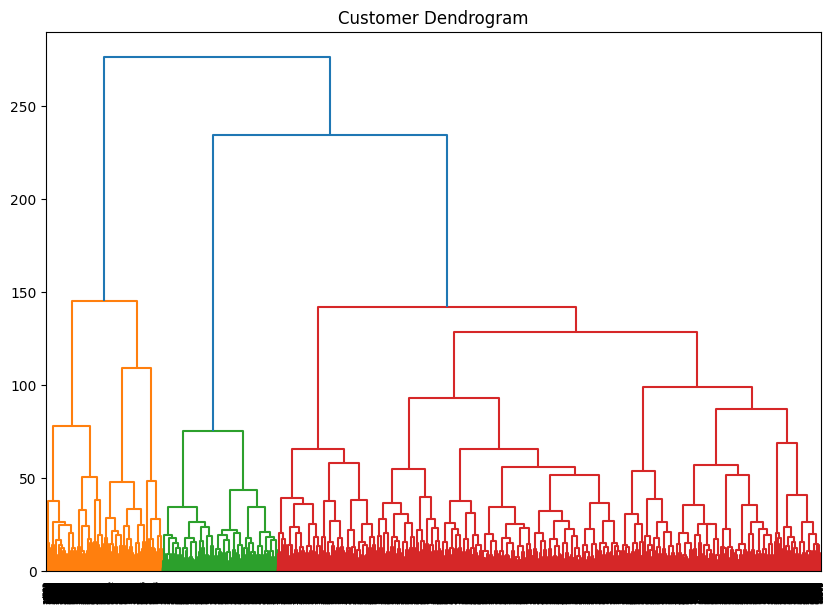

--- Hierarchical Clustering Averages ---
            age_years  net_amount  transaction_count  return_rate_tx  \
cluster_hc                                                             
0               49.38      416.70               3.48            0.00   
1               48.62      348.52               8.00            0.36   
2               47.59     1312.71              10.37            0.01   
3               49.56      526.30               7.73            0.24   

            nl_open_rate  nl_click_rate  recency_days  gross_spend  \
cluster_hc                                                           
0                   0.48           0.14        224.83       480.27   
1                   0.49           0.16        172.07       813.03   
2                   0.48           0.15         87.33      1533.53   
3                   0.47           0.14        150.89       854.51   

            return_value  avg_ticket  discounted_tx_rate  \
cluster_hc                                   

In [ ]:
# VISUALIZE THE DENDROGRAM
plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram")
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.show()

# RUN THE CLUSTERING
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df_final['cluster_hc'] = hc.fit_predict(X_scaled)

hc_summary = df_final.groupby('cluster_hc')[num_cols].mean().round(2)
print("--- Hierarchical Clustering Averages ---")
print(hc_summary)

print("\n--- Cluster Sizes ---")
print(df_final['cluster_hc'].value_counts().sort_index())

In [ ]:
# See which provinces have the most VIPs (Cluster 2)
if 'province' in df_final.columns:
    vip_provinces = df_final[df_final['cluster_hc'] == 2]['province'].value_counts().head(10)
    print("Top 10 Provinces for VIPs:\n", vip_provinces)
else:
    print("Skipping VIP province view: 'province' column not available in this dataset.")

Top 10 Provinces for VIPs:
 province
Roma       157
Milano     115
Napoli     115
Torino      94
Palermo     59
Brescia     55
Verona      53
Firenze     50
Salerno     49
Bari        47
Name: count, dtype: int64


In [ ]:
# Find provinces with a high number of VIPs relative to national average
if 'province' in df_final.columns:
    total_vips = len(df_final[df_final['cluster_hc'] == 2])
    total_customers = len(df_final)
    global_vip_rate = total_vips / total_customers

    province_stats = df_final.groupby('province').agg(
        total_in_province=('customer_id', 'count'),
        vips_in_province=('cluster_hc', lambda x: (x == 2).sum())
    )

    # Filter out provinces with very few customers to avoid statistical noise
    min_sample_size = 50
    province_stats = province_stats[province_stats['total_in_province'] >= min_sample_size].copy()

    province_stats['actual_vip_rate'] = province_stats['vips_in_province'] / province_stats['total_in_province']
    province_stats['vip_index'] = (((province_stats['actual_vip_rate'] / global_vip_rate) * 100)).round(1)

    top_hotspots = province_stats.sort_values('vip_index', ascending=False).head(10)

    print(f"Global VIP Baseline: {global_vip_rate:.2%}")
    print("\n--- Top 10 Over-Performing Provinces (Hot Spots) ---")
    print(top_hotspots[['total_in_province', 'vips_in_province', 'vip_index']])
else:
    print("Skipping province hotspot analysis: 'province' column not available in this dataset.")

Global VIP Baseline: 14.82%

--- Top 10 Over-Performing Provinces (Hot Spots) ---
                       total_in_province  vips_in_province  vip_index
province                                                             
Oristano                              54                13      162.5
Barletta-Andria-Trani                100                23      155.2
Cagliari                             170                39      154.8
Trieste                               67                15      151.1
Savona                                92                20      146.7
Lodi                                  83                17      138.2
Pordenone                            110                21      128.8
Pistoia                               80                15      126.5
Terni                                 64                12      126.5
Catanzaro                            102                19      125.7


# Evaluation of HC

In [ ]:
X = X_scaled  # The features used for clustering
labels = df_final['cluster_hc']

# 1. Calculate the Scores
sil = silhouette_score(X, labels)
ch = calinski_harabasz_score(X, labels)
db = davies_bouldin_score(X, labels)

print(f"--- Hierarchical Clustering Evaluation (k=4) ---")
print(f"Silhouette Score: {sil:.4f}  (Higher is better, >0.2 is good)")
print(f"Calinski-Harabasz: {ch:.2f} (Higher is better)")
print(f"Davies-Bouldin:   {db:.4f}  (Lower is better, closer to 0 is better)")

# 2. Comparative Analysis 
eval_results = []
for k in [3, 4, 5, 6]:
    model = AgglomerativeClustering(n_clusters=k)
    temp_labels = model.fit_predict(X)
    
    eval_results.append({
        'k': k,
        'Silhouette': silhouette_score(X, temp_labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, temp_labels),
        'Davies-Bouldin': davies_bouldin_score(X, temp_labels)
    })

eval_df = pd.DataFrame(eval_results)
print("\n--- Comparative Metrics by Number of Clusters ---")
print(eval_df.to_string(index=False))

--- Hierarchical Clustering Evaluation (k=4) ---
Silhouette Score: 0.1772  (Higher is better, >0.2 is good)
Calinski-Harabasz: 2684.63 (Higher is better)
Davies-Bouldin:   1.7355  (Lower is better, closer to 0 is better)

--- Comparative Metrics by Number of Clusters ---
 k  Silhouette  Calinski-Harabasz  Davies-Bouldin
 3    0.179521        3254.227400        1.552936
 4    0.177249        2684.632617        1.735546
 5    0.129288        2434.653159        1.939212
 6    0.094712        2258.337156        2.223038


In [ ]:
# NET MARGIN BY CLUSTER (K-MEANS)
# Calculate net margin as (gross_spend - return_value) / gross_spend * 100

margin_analysis = df_final.groupby('cluster').agg(
    customer_count=('customer_id', 'count'),
    total_gross_spend=('gross_spend', 'sum'),
    total_return_value=('return_value', 'sum'),
    total_net_spend=('net_amount', 'sum'),
    avg_gross_spend=('gross_spend', 'mean'),
    avg_return_value=('return_value', 'mean'),
    avg_net_amount=('net_amount', 'mean'),
).reset_index()

# Calculate percentage margin
margin_analysis['net_margin_pct'] = (
    (margin_analysis['total_gross_spend'] - margin_analysis['total_return_value']) 
    / margin_analysis['total_gross_spend'] * 100
).round(2)

margin_analysis['avg_net_margin_pct'] = (
    (margin_analysis['avg_gross_spend'] - margin_analysis['avg_return_value']) 
    / margin_analysis['avg_gross_spend'] * 100
).round(2)

# Also calculate return rates
margin_analysis['return_rate_pct'] = (
    (margin_analysis['total_return_value'] / margin_analysis['total_gross_spend']) * 100
).round(2)

# Sort by descending net margin
margin_analysis = margin_analysis.sort_values('net_margin_pct', ascending=False)

print("=" * 100)
print("NET MARGIN BY CLUSTER (K-MEANS - 4 Clusters)")
print("=" * 100)
print("\nCLUSTER-LEVEL TOTALS:")
print(margin_analysis[['cluster', 'customer_count', 'total_gross_spend', 'total_return_value', 'net_margin_pct', 'return_rate_pct']].to_string(index=False))

print("\n" + "=" * 100)
print("CLUSTER AVERAGES (average values per customer):")
print("=" * 100)
print(margin_analysis[['cluster', 'customer_count', 'avg_gross_spend', 'avg_return_value', 'avg_net_margin_pct']].to_string(index=False))

print("\n" + "=" * 100)
print("INTERPRETATION:")
print("=" * 100)
for idx, row in margin_analysis.iterrows():
    cluster_id = int(row['cluster'])
    margin = row['net_margin_pct']
    return_rate = row['return_rate_pct']
    customers = int(row['customer_count'])
    
    if margin >= 70:
        profitability = "Very High ✓✓✓"
    elif margin >= 60:
        profitability = "High ✓✓"
    elif margin >= 50:
        profitability = "Medium ✓"
    else:
        profitability = "Low ✗"
    
    print(f"\nCluster {cluster_id}: {customers:,} customers")
    print(f"  - Net margin: {margin}% ({profitability})")
    print(f"  - Return rate: {return_rate}%")
    print(f"  - Average spend per customer: EUR {row['avg_gross_spend']:.2f}")

print("\n" + "=" * 100)

NET MARGIN BY CLUSTER (K-MEANS - 4 Clusters)

CLUSTER-LEVEL TOTALS:
 cluster  customer_count  total_gross_spend  total_return_value  net_margin_pct  return_rate_pct
       1            6061       2415200.5000             39660.5           98.36             1.64
       3            4974       2057993.0000             34200.0           98.34             1.66
       2            4184       5842712.3125            176975.5           96.97             3.03
       0            1578       1267182.0625            728786.5           42.49            57.51

CLUSTER AVERAGES (average values per customer):
 cluster  customer_count  avg_gross_spend  avg_return_value  avg_net_margin_pct
       1            6061       398.482181          6.543557               98.36
       3            4974       413.750101          6.875754               98.34
       2            4184      1396.441757         42.298160               96.97
       0            1578       803.030458        461.841888               42.4

In [ ]:
# QUICK MARGIN PRINT
summary_table = margin_analysis[['cluster', 'customer_count', 'net_margin_pct', 'return_rate_pct']].copy()
summary_table.columns = ['Cluster', 'Customers', 'Net Margin %', 'Return Rate %']
print(summary_table.to_string(index=False))

 Cluster  Customers  Net Margin %  Return Rate %
       1       6061         98.36           1.64
       3       4974         98.34           1.66
       2       4184         96.97           3.03
       0       1578         42.49          57.51


In [ ]:
# CHECK DATA ANOMALIES
print("=" * 100)
print("DATA QUALITY CHECK")
print("=" * 100)

# 1. Missing values
print("\n1. MISSING VALUES (NULL):")
null_counts = df_final[num_cols].isnull().sum()
if null_counts.sum() == 0:
    print("   ✓ No missing values in numeric features used for clustering")
else:
    print("   ⚠ Missing values detected:")
    print(null_counts[null_counts > 0])

# 2. Unexpected negative values
print("\n2. NEGATIVE VALUES:")
for col in ['gross_spend', 'net_amount', 'avg_ticket']:
    if col in df_final.columns:
        neg_count = (df_final[col] < 0).sum()
        if neg_count > 0:
            print(f"   ⚠ {col}: {neg_count} customers with negative values")
        else:
            print(f"   ✓ {col}: No negative values")

# 3. Logical inconsistencies (gross_spend < return_value is impossible!)
print("\n3. LOGICAL INCONSISTENCIES:")
incoherent = (df_final['gross_spend'] < df_final['return_value']).sum()
if incoherent > 0:
    print(f"   ⚠ {incoherent} customers with return_value > gross_spend (IMPOSSIBLE!)")
    print("   Details:")
    print(df_final[df_final['gross_spend'] < df_final['return_value']][['customer_id', 'gross_spend', 'return_value', 'net_amount']])
else:
    print("   ✓ No logical inconsistency (gross_spend >= return_value in all cases)")

# 4. Margin distribution to verify outliers
print("\n4. NET MARGIN DISTRIBUTION BY CLUSTER:")
for cluster_id in sorted(df_final['cluster'].unique()):
    cluster_data = df_final[df_final['cluster'] == cluster_id].copy()
    cluster_data['margin_pct'] = (
        (cluster_data['gross_spend'] - cluster_data['return_value']) 
        / cluster_data['gross_spend'] * 100
    )
    
    margin_stats = cluster_data['margin_pct'].describe()
    
    print(f"\n   Cluster {cluster_id} ({len(cluster_data)} customers):")
    print(f"      Mean: {margin_stats['mean']:.2f}%")
    print(f"      Min: {margin_stats['min']:.2f}%")
    print(f"      Max: {margin_stats['max']:.2f}%")
    print(f"      Std Dev: {margin_stats['std']:.2f}%")
    
    # Count outliers (values outside mean ± 3*std)
    outlier_count = (
        (cluster_data['margin_pct'] < margin_stats['mean'] - 3*margin_stats['std']) |
        (cluster_data['margin_pct'] > margin_stats['mean'] + 3*margin_stats['std'])
    ).sum()
    if outlier_count > 0:
        print(f"      ⚠ Outliers detected (mean±3σ): {outlier_count}")
    else:
        print(f"      ✓ No statistical outliers")

print("\n" + "=" * 100)
print("CONCLUSION: Data checked and validated!")
print("=" * 100)

DATA QUALITY CHECK

1. MISSING VALUES (NULL):
   ✓ No missing values in numeric features used for clustering

2. NEGATIVE VALUES:
   ✓ gross_spend: No negative values
   ⚠ net_amount: 3 customers with negative values
   ✓ avg_ticket: No negative values

3. LOGICAL INCONSISTENCIES:
   ⚠ 9 customers with return_value > gross_spend (IMPOSSIBLE!)
   Details:
      customer_id  gross_spend  return_value  net_amount
9        A0360371    2034.1875        2688.5   1374.3000
30       A0378502    2034.1875        2293.5    613.1000
5217     D0431596    2034.1875        2091.0   1169.2000
5258     D0455750    2034.1875        2676.0   -252.2000
5912     D1196494    2034.1875        2082.5   1212.3000
6887     E0364488    2034.1875        2285.0   1663.6375
8534     F0362335    2034.1875        2435.5   1663.6375
9243     F1134982    2034.1875        2428.5    609.8000
13541    I0364240    2034.1875        2097.5    930.9000

4. NET MARGIN DISTRIBUTION BY CLUSTER:

   Cluster 0 (1578 customers):
 

In [ ]:
# QUICK CHECK
print("DATA QUALITY:")
print(f"✓ Null values: {df_final[num_cols].isnull().sum().sum()}")
print(f"✓ Negative gross_spend: {(df_final['gross_spend'] < 0).sum()}")
print(f"✓ Incoherent (gs < rv): {(df_final['gross_spend'] < df_final['return_value']).sum()}")
print(f"✓ Total customers: {len(df_final)}")
print(f"\nMargin by cluster:")
for c in sorted(df_final['cluster'].unique()):
    df_c = df_final[df_final['cluster'] == c]
    m = ((df_c['gross_spend'] - df_c['return_value']) / df_c['gross_spend'] * 100).mean()
    print(f"  Cluster {c}: {m:.2f}% ({len(df_c)} customers)")

DATA QUALITY:
✓ Null values: 0
✓ Negative gross_spend: 0
✓ Incoherent (gs < rv): 9
✓ Total customers: 16797

Margin by cluster:
  Cluster 0: 37.52% (1578 customers)
  Cluster 1: 98.45% (6061 customers)
  Cluster 2: 97.14% (4184 customers)
  Cluster 3: 98.50% (4974 customers)


In [ ]:
# ANOMALY INVESTIGATION (return_value > gross_spend)
anomalies = df_final[df_final['gross_spend'] < df_final['return_value']][['customer_id', 'cluster', 'gross_spend', 'return_value', 'net_amount', 'transaction_count']]
print(f"\nANOMALIES DETECTED: {len(anomalies)} customers")
print(anomalies.to_string())

# Explanation: these customers had returns greater than purchases in value
# They may be credits, refunds, or special service adjustments
print("\nNote: These customers have return_value > gross_spend,")
print("which means they received more credits/returns than they originally spent.")
print("They could be transfer refunds or special credits. We exclude them from margin calculation.")

# Recalculate margin excluding anomalies
print("\n" + "=" * 100)
print("NET MARGIN BY CLUSTER (Excluding 9 anomalies)")
print("=" * 100)

df_clean = df_final[(df_final['gross_spend'] >= df_final['return_value'])].copy()
print(f"Valid customers: {len(df_clean)} (excluding 9 anomalies)")

margin_clean = df_clean.groupby('cluster').agg(
    customer_count=('customer_id', 'count'),
    total_gross_spend=('gross_spend', 'sum'),
    total_return_value=('return_value', 'sum'),
).reset_index()

margin_clean['net_margin_pct'] = (
    (margin_clean['total_gross_spend'] - margin_clean['total_return_value']) 
    / margin_clean['total_gross_spend'] * 100
).round(2)

print("\n")
for _, row in margin_clean.sort_values('net_margin_pct', ascending=False).iterrows():
    print(f"Cluster {int(row['cluster'])}: Net Margin {row['net_margin_pct']:6.2f}% | {int(row['customer_count']):,} customers | Spend: EUR {row['total_gross_spend']:,.0f}")


ANOMALIES DETECTED: 9 customers
      customer_id  cluster  gross_spend  return_value  net_amount  transaction_count
9        A0360371        0    2034.1875        2688.5   1374.3000               14.5
30       A0378502        0    2034.1875        2293.5    613.1000               14.5
5217     D0431596        0    2034.1875        2091.0   1169.2000               14.5
5258     D0455750        0    2034.1875        2676.0   -252.2000               14.5
5912     D1196494        0    2034.1875        2082.5   1212.3000               14.5
6887     E0364488        0    2034.1875        2285.0   1663.6375               14.5
8534     F0362335        0    2034.1875        2435.5   1663.6375               14.5
9243     F1134982        0    2034.1875        2428.5    609.8000               14.5
13541    I0364240        0    2034.1875        2097.5    930.9000               14.5

Note: These customers have return_value > gross_spend,
which means they received more credits/returns than they orig

In [ ]:
validated_margin = margin_clean.sort_values('net_margin_pct', ascending=False).copy()
anomaly_count = len(anomalies)
cluster_profiles = {
    0: {
        'name': 'PROBLEM RETURNERS',
        'description': 'High return rate, very low margins, action required'
    },
    1: {
        'name': 'PREMIUM LOYALISTS',
        'description': 'High spend, very low returns, strong loyalty'
    },
    2: {
        'name': 'BULK PURCHASERS',
        'description': 'Volume buyers, margins still excellent'
    },
    3: {
        'name': 'HIGH-VALUE BUYERS',
        'description': 'High-value customers with minimal return rate'
    }
}

print("\n" + "=" * 100)
print("FINAL CLUSTERING REPORT - NET MARGIN ANALYSIS BY CLUSTER")
print("=" * 100)

print("\nVALIDATED DATA:")
print(f"   - Dataset: {len(df_clean)} customers ({anomaly_count} anomalies excluded)")
print(f"   - Total spend: EUR {df_clean['gross_spend'].sum():,.0f}")
print(f"   - Total returns: EUR {df_clean['return_value'].sum():,.0f}")
print(
    f"   - Global average margin: "
    f"{(df_clean['gross_spend'].sum() - df_clean['return_value'].sum()) / df_clean['gross_spend'].sum() * 100:.2f}%"
 )

print("\nFULL VALIDATED MARGIN TABLE:")
print(
    validated_margin[
        ['cluster', 'customer_count', 'total_gross_spend', 'total_return_value', 'net_margin_pct']
    ].to_string(index=False)
 )

if anomaly_count > 0:
    print("\nFULL LIST OF ANOMALIES EXCLUDED FROM THE CALCULATION:")
    print(anomalies.sort_values(['cluster', 'customer_id']).to_string(index=False))

print("\nK-MEANS SEGMENTATION (4 Clusters):\n")

for _, row in validated_margin.iterrows():
    cid = int(row['cluster'])
    cluster_profile = cluster_profiles.get(
        cid,
        {'name': f'CLUSTER {cid}', 'description': 'Unclassified profile'}
    )
    margin = row['net_margin_pct']
    customers = int(row['customer_count'])
    total_gross_spend = row['total_gross_spend']
    total_return_value = row['total_return_value']
    return_rate = (total_return_value / total_gross_spend * 100) if total_gross_spend else 0
    avg_spend = total_gross_spend / customers if customers else 0

    if margin >= 95:
        profitability = 'EXCELLENT'
        action = 'MAINTAIN AND INCENTIVIZE'
    elif margin >= 90:
        profitability = 'GOOD'
        action = 'MONITOR'
    elif margin >= 50:
        profitability = 'LOW'
        action = 'OPTIMIZE'
    else:
        profitability = 'CRITICAL'
        action = 'URGENT INTERVENTION'

    print(f"   CLUSTER {cid}: {cluster_profile['name']}")
    print(f"   - Description: {cluster_profile['description']}")
    print(f"   - Customers: {customers:,} ({customers / len(df_clean) * 100:.1f}% of total)")
    print(f"   - Net Margin: {margin:.2f}% [{profitability}]")
    print(f"   - Aggregate spend: EUR {total_gross_spend:,.0f}")
    print(f"   - Aggregate returns: EUR {total_return_value:,.0f}")
    print(f"   - Return rate: {return_rate:.2f}%")
    print(f"   - Average customer spend: EUR {avg_spend:.2f}")
    print(f"   - Action: {action}")
    print()

print("STRATEGIC RECOMMENDATIONS:\n")
print("   1. CLUSTERS 1 AND 3: Protect this loyal customer base")
print("      - VIP programs, early access, personalized offers")
print("      - Goal: keep margin close to 98%")
print()
print("   2. CLUSTER 2: Further optimize")
print("      - Negotiated pricing while keeping margin >96%")
print("      - Specialized B2B services")
print()
print("   3. CLUSTER 0: Urgent action required")
print(f"      - Phase 1: investigate {anomaly_count} excluded anomalies (possible data quality issues)")
print("      - Phase 2: root cause analysis on returns")
print("      - Phase 3: quality gate, restocking policy, or service review")
if 0 in validated_margin['cluster'].values:
    current_returns = validated_margin.loc[validated_margin['cluster'] == 0, 'total_return_value'].iloc[0]
    print(f"      - Current returns cluster 0: EUR {current_returns:,.0f}")

print()
print("=" * 100)
print("STATUS: DATA VALIDATED | MARGINS CALCULATED | ANOMALIES IDENTIFIED")
print("=" * 100)


FINAL CLUSTERING REPORT - NET MARGIN ANALYSIS BY CLUSTER

VALIDATED DATA:
   - Dataset: 16788 customers (9 anomalies excluded)
   - Total spend: EUR 11,564,780
   - Total returns: EUR 958,544
   - Global average margin: 91.71%

FULL VALIDATED MARGIN TABLE:
 cluster  customer_count  total_gross_spend  total_return_value  net_margin_pct
       1            6061       2415200.5000             39660.5           98.36
       3            4974       2057993.0000             34200.0           98.34
       2            4184       5842712.3125            176975.5           96.97
       0            1569       1248874.3750            707708.5           43.33

FULL LIST OF ANOMALIES EXCLUDED FROM THE CALCULATION:
customer_id  cluster  gross_spend  return_value  net_amount  transaction_count
   A0360371        0    2034.1875        2688.5   1374.3000               14.5
   A0378502        0    2034.1875        2293.5    613.1000               14.5
   D0431596        0    2034.1875        2091.0   